<a href="https://colab.research.google.com/github/BretteFitzgibbon/Spotify_Cluster_Analysis/blob/main/Copy_of_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

Spotify has more than 100 million songs by 8.4 million artists, and 60,000 new songs are added per day. To help users discover new music, it has more than 1,500 AI-generated playlists, with names like Bossa Pop, Get Turnt, New Noise, You & Me, and Terra Incognita. In my experience, the songs in these playlists work well together and create different vibes for listeners to enjoy based on their current mood. I wondered how Spotify makes these playlists: what similarities do the songs have, and which features are the most important factors that group certain songs together?

I was overjoyed to find a Kaggle dataset on 232,725 Spotify songs with 18 features. These features gave insight on what makes certain songs go together. The most consequential are as follows:

 -- Genre

 -- Popularity

 -- Acousticness

 -- Danceability

 -- Energy

 -- Instrumentalness

 -- Key

 -- Liveness

 -- Loudness

 -- Mode

 -- Speechiness

 -- Tempo

 -- Time Signature

 -- Valence

**Definitions**

-- Genre: a subjectively defined, human-created label that groups songs based on such features as instruments, production style, rhythm, structure, cultural context, time period, and lyrical themes. In Spotify, genre assessment comes from metadata like artist tagging and industry classification that is applied to Spotify's internal taxonomy.

-- Popularity: measured by number of plays and recency of plays

-- Acousticness: measured by spectral features and the presence or absence of electronic signatures (acoustic songs will not have electronic signatures)

-- Danceability: whether people would want to dance to it or not. Based on tempo stability, beat strength, and rhythm regularity.

-- Energy: intensity level. Based on loudness, dynamic range, adn timbre.

-- Instrumentalness: the absence of vocals. Measured by vocal detection models.

-- Key: the tonal center of the song, encoded in 12 pitch classes: A, A#, B, C, C#, D, D#, E, F, F#, G, G#. These pitch classes repeat for each octave, making G#, for example, closer to the A of the next octave than the F# of the current. Spotify extracts key using pitch detection algorithms that look at dominant frequencies and harmonic structure.

-- Liveness: whether the track is recorded live. Based on audience noise and reverberation patterns.

-- Loudness: measured by the average amplitude of the audio signal

-- Mode: major and minor. The modes interact with the keys (for example, A-major and A-minor). The major mode sounds brighter and happier, while the minor mode is darker and sadder. Spotify extracts mode based on the interval structure of the detected key, with an algorithm determining whther the scale matches the major or minor pattern.

-- Speechiness: whether there are spoken words. Measured based on vocal patterns versus musical tones.

-- Tempo: the speed of the track in beats per minute, measured through beat detection algorithms

-- Time signature: the number of beats per measure. 4/4 (4 beats per measure) is the most common. Measured by the tempo and the periodic structure of beats.

-- Valence: whether a song sounds positive or negative. Based on harmony, timbre, tempo, and mode.

**Why K-means?**

Since the goal was to group songs into playlists based on shared characteristics, I thought an unsupervised grouping algorithm, K-means, would be best. Unlike correlation and classification problems that use supervised learning, grouping songs into playlists has no one "right" answer.

**The Dataset**

https://www.kaggle.com/datasets/zaheenhamidani/ultimate-spotify-tracks-db?resource=download

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Python Modules to Install**

-- Pandas

-- NumPy

-- Matplotlib

-- Seaborn

-- Scikit-learn

**Overall Program**

-- Separated categorical and numerical features

-- Performed binary encoding, circular encoding with sine and cosine, and one-hot encoding on the categorical features

-- Used a StandardScaler() object to scale the numerical features

-- Used the K-means elbow method to select the appropriate K (9)

-- Ran K-means on the data to group the songs into 9 clusters

-- Performed principal component analysis to display the nine-dimensional data on an x-y coordinate plane

-- For each cluster, found the 20 data points closest to the centroids to find the most quintessential songs of the cluster

-- Found these songs on Spotify and manually built nine playlists

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SpotifyFeatures.csv')

**Data Preparation**

-- Obtained the columns and printed their unique values to see which were categorical and which were numerical

-- Checked for null and NaN values

-- Found the Children's Music genre listed twice, once with a curly apostrophe. Replaced the curly apostrophe with a straight apostrophe to merge the song counts under one Children's Music genre.

In [ ]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [ ]:
df.shape

(232725, 18)

**Check for Null Values**

In [ ]:
df.isnull().sum()

,0
genre,0
artist_name,0
track_name,1
track_id,0
popularity,0
acousticness,0
danceability,0
duration_ms,0
energy,0
instrumentalness,0


**Get the unique values of each feature to see if they are categorical or continuous**

In [ ]:
print(df["genre"].unique())

['Movie' 'R&B' 'A Capella' 'Alternative' 'Country' 'Dance' 'Electronic'
 'Anime' 'Folk' 'Blues' 'Opera' 'Hip-Hop' "Children's Music"
 'Children’s Music' 'Rap' 'Indie' 'Classical' 'Pop' 'Reggae' 'Reggaeton'
 'Jazz' 'Rock' 'Ska' 'Comedy' 'Soul' 'Soundtrack' 'World']


"Children's Music" appears twice, once with a curly apostrophe, leading the genre's value counts to be split

**Merge the curly apostrophe category into the main category**

In [ ]:
df['genre'] = df['genre'].str.replace('’', "'", regex=False)

In [ ]:
print(df['genre'].value_counts())

genre
Children's Music    14756
Comedy               9681
Soundtrack           9646
Indie                9543
Jazz                 9441
Pop                  9386
Electronic           9377
Folk                 9299
Hip-Hop              9295
Rock                 9272
Alternative          9263
Classical            9256
Rap                  9232
World                9096
Soul                 9089
Blues                9023
R&B                  8992
Anime                8936
Reggaeton            8927
Ska                  8874
Reggae               8771
Dance                8701
Country              8664
Opera                8280
Movie                7806
A Capella             119
Name: count, dtype: int64


In [ ]:
print(df["popularity"].unique())

[  0   1   3   4   2  15  10   8   5   6   7  11  65  63  62  61  68  64
  66  60  69  71  76  67  70  72  57  59  56  28  31  74  55  53   9  13
  23  12  44  33  25  26  24  22  20  19  18  16  17  14  83  81  73  78
  77  75  45  42  46  54  41  52  58  51  43  47  48  40  50  49  39  80
  37  35  21  38  36  29  34  32  99 100  97  92  91  95  90  93  88  87
  89  96  86  85  84  94  82  79  27  30  98]


In [ ]:
print(df["acousticness"].unique())

[6.11e-01 2.46e-01 9.52e-01 ... 4.02e-05 9.25e-05 6.93e-06]


In [ ]:
print(df["danceability"].unique())

[0.389  0.59   0.663  ... 0.0584 0.0577 0.057 ]


In [ ]:
print(df["energy"].unique())

[0.91    0.737   0.131   ... 0.00701 0.00156 0.00633]


In [ ]:
print(df["instrumentalness"].unique())

[0.      0.123   0.00086 ... 0.00667 0.0646  0.00699]


In [ ]:
print(df["key"].unique())

['C#' 'F#' 'C' 'F' 'G' 'E' 'D#' 'G#' 'D' 'A#' 'A' 'B']


In [ ]:
print(df["liveness"].unique())

[0.346  0.151  0.103  ... 0.02   0.0143 0.0189]


In [ ]:
print(df["loudness"].unique())

[ -1.828  -5.559 -13.879 ... -16.444 -14.11  -18.792]


In [ ]:
print(df["mode"].unique())

['Major' 'Minor']


In [ ]:
print(df["speechiness"].unique())

[0.0525 0.0868 0.0362 ... 0.618  0.607  0.687 ]


In [ ]:
print(df["tempo"].unique())

[166.969 174.003  99.488 ... 113.112 172.968 175.666]


In [ ]:
print(df["time_signature"].unique())

['4/4' '5/4' '3/4' '1/4' '0/4']


In [ ]:
print(df["valence"].unique())

[0.814  0.816  0.368  ... 0.018  0.0209 0.0248]


In [ ]:
df.dropna(subset = ["acousticness", "danceability", "energy", "instrumentalness", "liveness", "loudness", "speechiness", "tempo", "valence"], how = "any", inplace = True)

Good news -- there were no NaN rows!

In [ ]:
df.shape

(232725, 18)

The categorical features are genre, key, mode, and time signature.

**What can we say about the overall data?**

-- Children's music is the largest genre group, at around 6 percent of the songs. A capella is negligible. All of the others are close to equal, at around 4% each.

-- The keys of C, G, D, A, and C# are the most common, each comprising 9-11 percent of the songs.

-- The major mode is about twice as common as the minor mode.

-- More than 90 percent of the songs have a 4/4 time signature.

**Overall Genre Distribution**

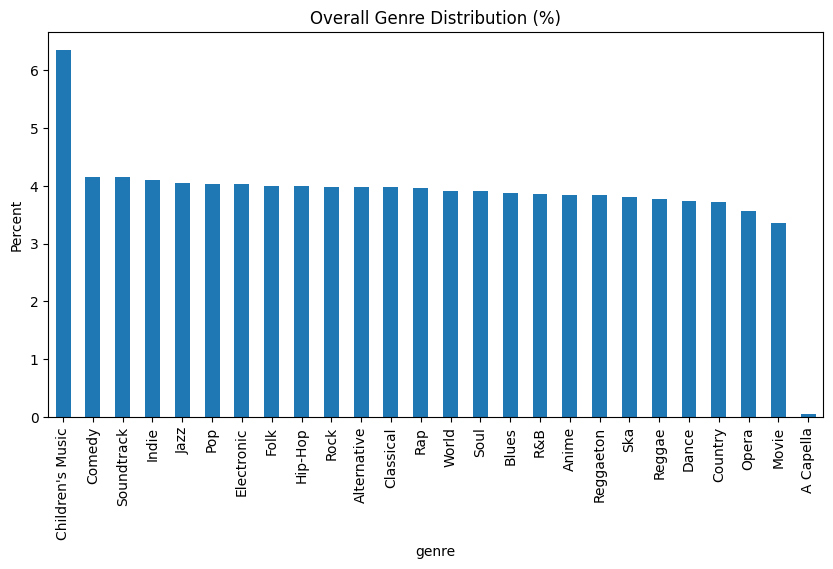

In [ ]:
genre_overall = df["genre"].value_counts(normalize=True) * 100

genre_overall.sort_values(ascending=False).plot(
    kind="bar",
    title="Overall Genre Distribution (%)",
    figsize=(10, 5)
)

plt.ylabel("Percent")
plt.show()

**Overall Key Distribution**

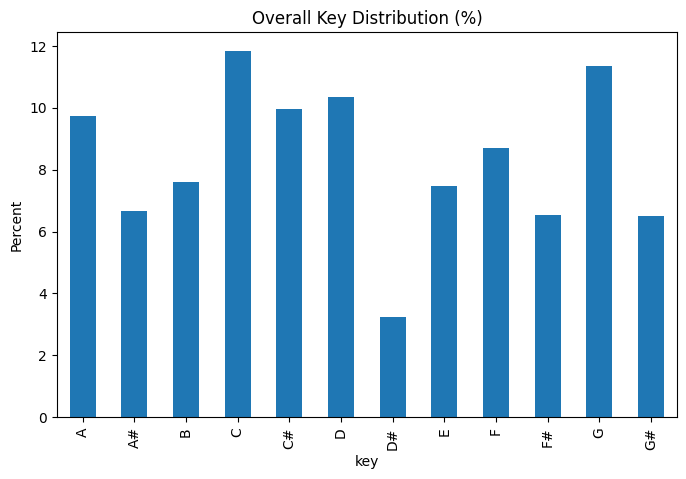

In [ ]:
key_overall = df["key"].value_counts(normalize=True) * 100

key_overall.sort_index().plot(
    kind="bar",
    title="Overall Key Distribution (%)",
    figsize=(8, 5)
)

plt.ylabel("Percent")
plt.show()

**Overall Mode Distribution**

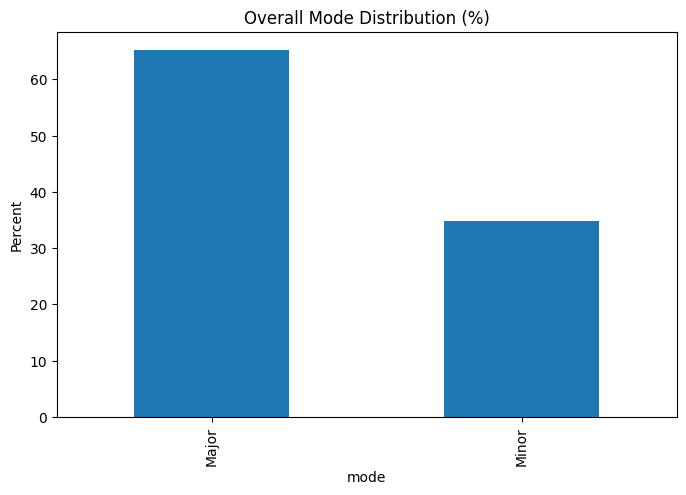

In [ ]:
ts_overall = df["mode"].value_counts(normalize=True) * 100

ts_overall.sort_index().plot(
    kind="bar",
    title="Overall Mode Distribution (%)",
    figsize=(8, 5)
)

plt.ylabel("Percent")
plt.show()

**Overall Time Signature Distribution**

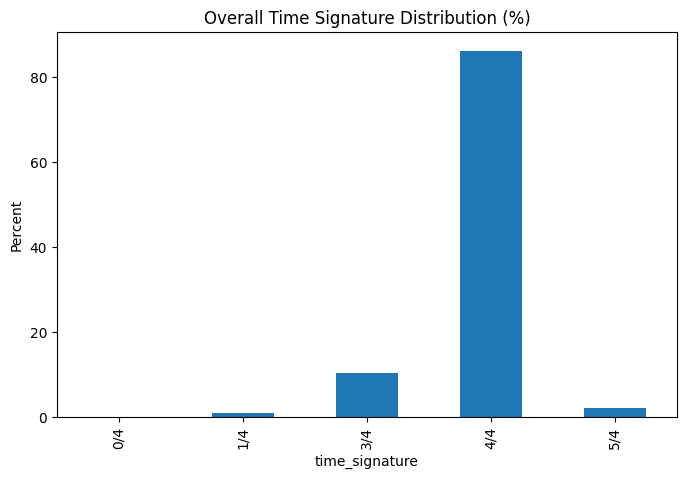

In [ ]:
ts_overall = df["time_signature"].value_counts(normalize=True) * 100

ts_overall.sort_index().plot(
    kind="bar",
    title="Overall Time Signature Distribution (%)",
    figsize=(8, 5)
)

plt.ylabel("Percent")
plt.show()

**Categorical Feature Encoding**

Binary Encoding for Mode

In [ ]:
df["mode"] = df["mode"].map({ "Major": 0, "Minor": 1})

Circular encoding with sine and cosine. The data recognizes pitch class from A to G#, but not absolute pitch (which would count keys in different octaves as different values).

In [ ]:
key_map = {
    "C": 0, "C#": 1, "D": 2, "D#": 3,
    "E": 4, "F": 5, "F#": 6, "G": 7,
    "G#": 8, "A": 9, "A#": 10, "B": 11
}

df["key_num"] = df["key"].map(key_map)

df["key_sin"] = np.sin(2 * np.pi * df["key_num"] / 12)
df["key_cos"] = np.cos(2 * np.pi * df["key_num"] / 12)

One-hot encoding for genre and time signature

In [ ]:
cat_features = ["genre", "time_signature"]
x_cat = df[cat_features]
num_features = ["popularity", "acousticness", "danceability", "energy", "instrumentalness", "liveness", "loudness", "speechiness", "tempo", "valence"]
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
x_cat_encoded = encoder.fit_transform(x_cat)

**Scale Numerical Features**

In [ ]:
scaler = StandardScaler()
x_num = df[["popularity", "acousticness", "danceability", "energy", "instrumentalness", "liveness", "loudness", "speechiness", "tempo", "valence"]]
x_num_scaled = scaler.fit_transform(x_num)

Combine encoded and scaled values in a horizontal stack

In [ ]:
x_final = np.hstack([x_num_scaled, x_cat_encoded])

**Find the Best K Value**

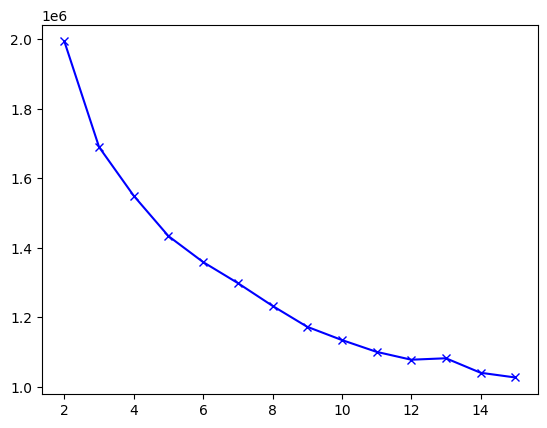

In [ ]:
K = range(2, 16)
inertia_list = []
for k in K:
  kmeanModel = KMeans(n_clusters = k, n_init = "auto").fit(x_final)
  inertia_list.append(kmeanModel.inertia_)
plt.plot(K, inertia_list, 'bx-')
plt.show()

**Apply K-means with 9 Clusters**

In [ ]:
km = KMeans(n_clusters = 9, init = 'random', n_init = 10, max_iter = 300, tol = 1e-04, random_state = 0)

In [ ]:
clusters = km.fit_predict(x_final)
df["cluster"] = clusters

**Use principal component analysis to plot the results in two dimensions**

In [ ]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_final)
centroids_pca = pca.transform(km.cluster_centers_)

**Plot Clusters**

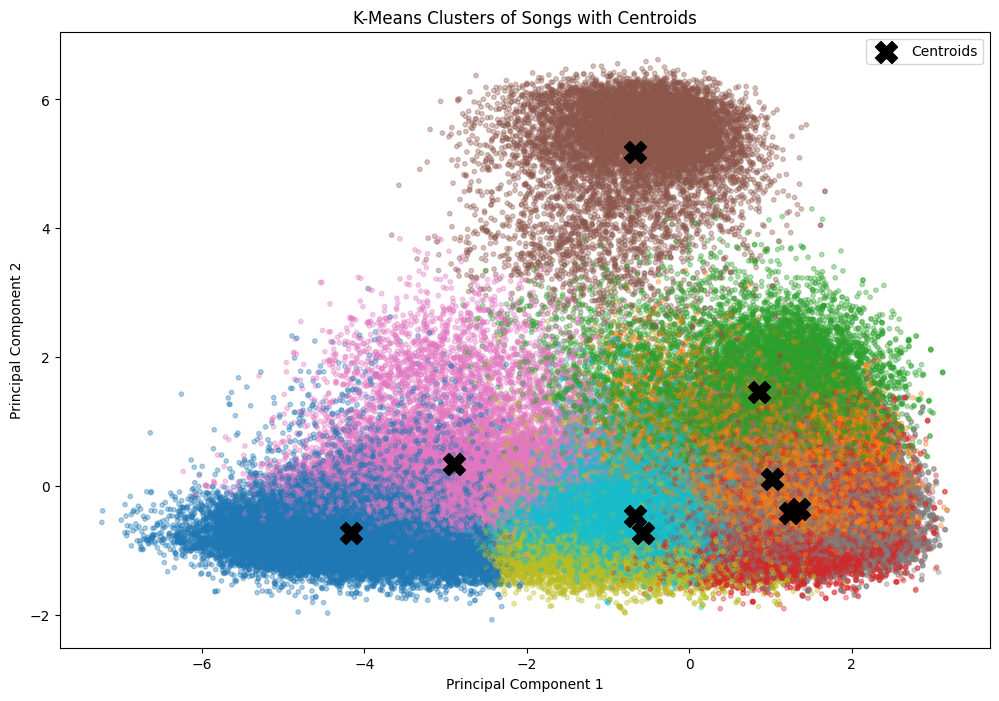

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=clusters,
    cmap="tab10",
    alpha=0.35,
    s=10
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="black",
    s=250,
    marker="X",
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters of Songs with Centroids")
plt.legend()
plt.show()

**How Many Songs per Cluster?**

In [ ]:
df["cluster"].value_counts()

,count
cluster,
6,56527
3,37895
8,32559
1,32553
0,20733
7,15481
5,15145
2,12078
4,9754


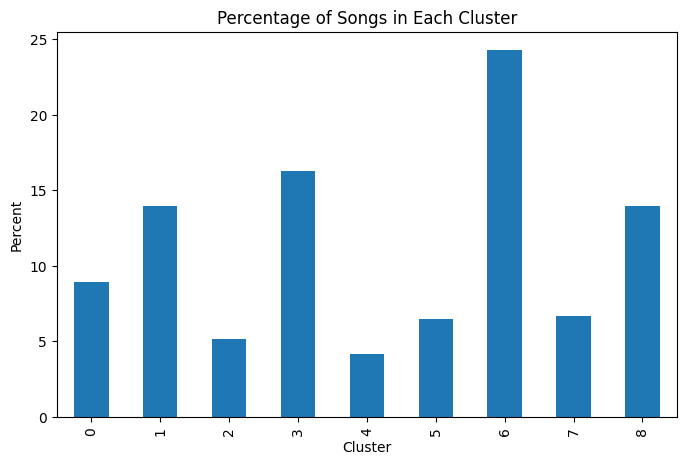

In [ ]:
cluster_pct = df["cluster"].value_counts(normalize=True).sort_index() * 100

cluster_pct.plot(
    kind="bar",
    title="Percentage of Songs in Each Cluster",
    figsize=(8, 5)
)

plt.ylabel("Percent")
plt.xlabel("Cluster")
plt.show()

**Genre Breakdown**

In [ ]:
pd.set_option("display.max_columns", None)
display(pd.crosstab(df["cluster"], df["genre"], normalize="index"))

genre,A Capella,Alternative,Anime,Blues,Children's Music,Classical,Comedy,Country,Dance,Electronic,Folk,Hip-Hop,Indie,Jazz,Movie,Opera,Pop,R&B,Rap,Reggae,Reggaeton,Rock,Ska,Soul,Soundtrack,World
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000820,0.064390,0.002315,0.010322,0.296870,0.000000,0.000096,0.000241,0.005595,0.009068,0.000000,0.004100,0.041576,0.043891,0.090870,0.001302,0.000531,0.000193,0.000048,0.000000,0.002701,0.000000,0.003762,0.358993,0.062316
1,0.000676,0.011397,0.055018,0.086659,0.104230,0.001198,0.006820,0.042607,0.010905,0.029982,0.021688,0.003963,0.007926,0.045925,0.067674,0.000154,0.000676,0.015605,0.001751,0.159617,0.144503,0.006297,0.107394,0.043805,0.000829,0.022701
2,0.000000,0.046531,0.024673,0.088508,0.050588,0.006210,0.012419,0.032373,0.036844,0.064829,0.032042,0.046365,0.024839,0.029309,0.032787,0.004802,0.027571,0.031793,0.042308,0.050008,0.050836,0.036927,0.087514,0.039079,0.002235,0.098609
3,0.000026,0.084549,0.078374,0.049400,0.081805,0.010292,0.001003,0.064995,0.040665,0.062726,0.033725,0.030954,0.045468,0.011611,0.005542,0.000026,0.035968,0.030453,0.034358,0.026441,0.038264,0.066104,0.089537,0.026204,0.001214,0.050297
4,0.000000,0.000615,0.000000,0.001845,0.016814,0.001333,0.928132,0.000000,0.000000,0.000513,0.000308,0.002563,0.000308,0.001435,0.036805,0.002255,0.000205,0.001333,0.001743,0.000820,0.000308,0.000103,0.001230,0.000820,0.000205,0.000308
5,0.005744,0.000792,0.026411,0.023902,0.069330,0.128623,0.005943,0.002905,0.000198,0.001651,0.015385,0.000000,0.002047,0.032288,0.199076,0.409640,0.000066,0.001321,0.000000,0.000726,0.000000,0.000594,0.001056,0.006537,0.033278,0.032486
6,0.000000,0.057194,0.004971,0.009005,0.065632,0.001291,0.000230,0.039892,0.093920,0.023599,0.028818,0.117625,0.058998,0.011729,0.000460,0.000000,0.107772,0.074548,0.116794,0.021689,0.033683,0.073222,0.006722,0.045023,0.000124,0.007059
7,0.000000,0.027647,0.091725,0.041212,0.059944,0.018151,0.000000,0.000969,0.014857,0.216136,0.031264,0.004328,0.038111,0.184097,0.007622,0.004328,0.004328,0.010529,0.002519,0.018991,0.000517,0.019314,0.024675,0.025709,0.084814,0.068213
8,0.000276,0.043920,0.013545,0.051783,0.048712,0.008661,0.003532,0.064713,0.024970,0.012746,0.134863,0.021254,0.098836,0.069842,0.017476,0.001198,0.045425,0.077552,0.021499,0.013176,0.007494,0.049510,0.004238,0.094290,0.008508,0.061980


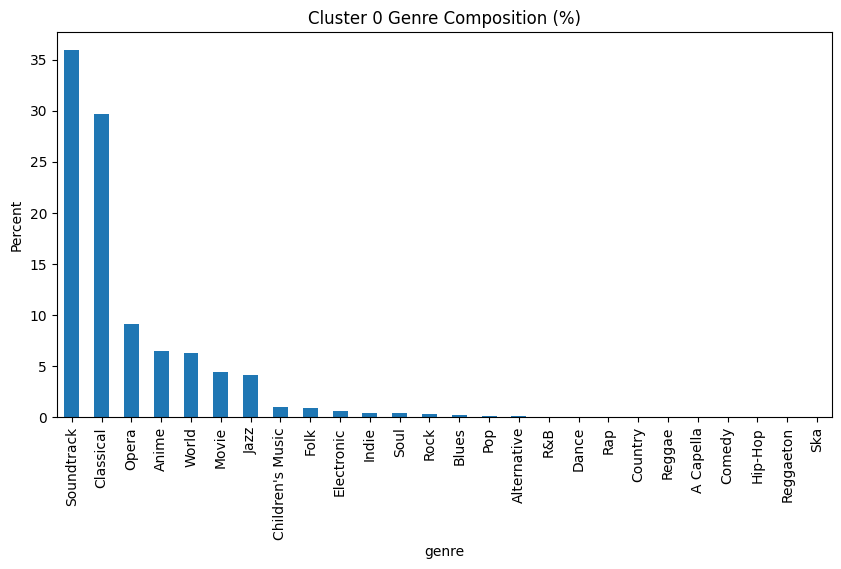

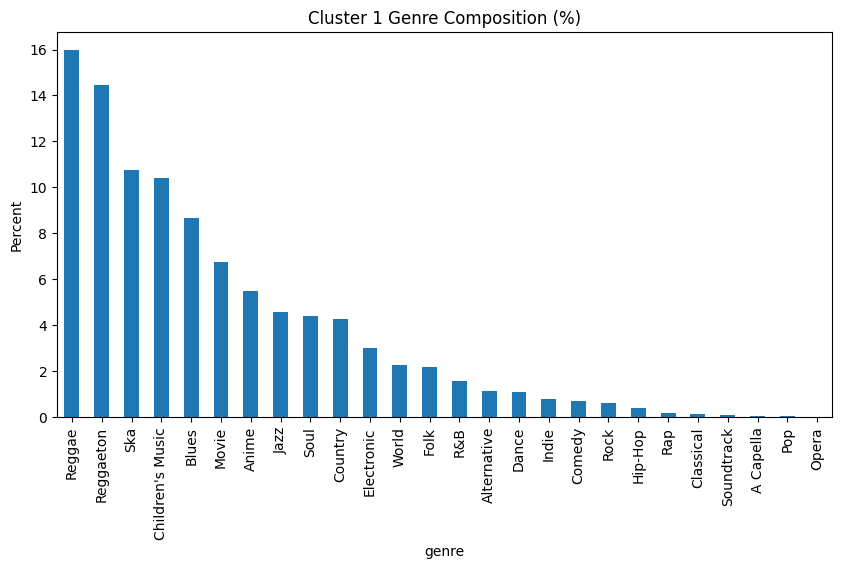

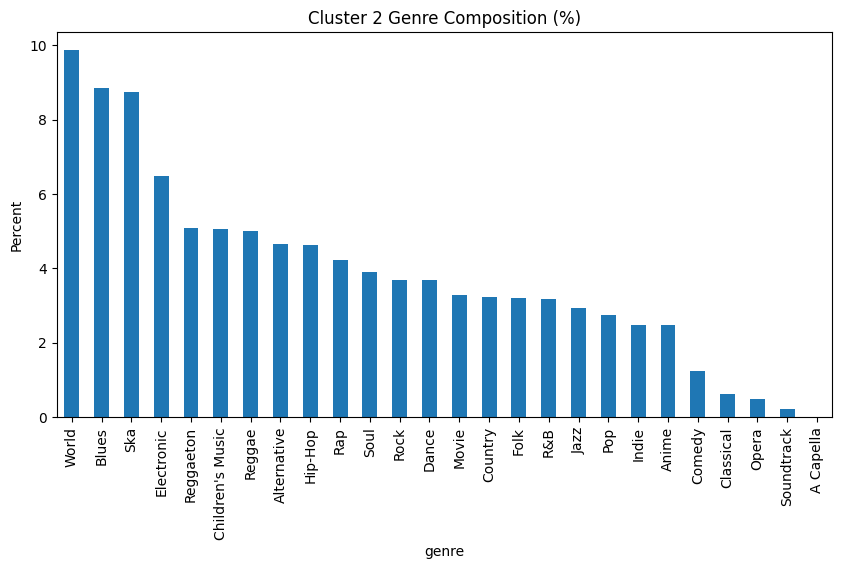

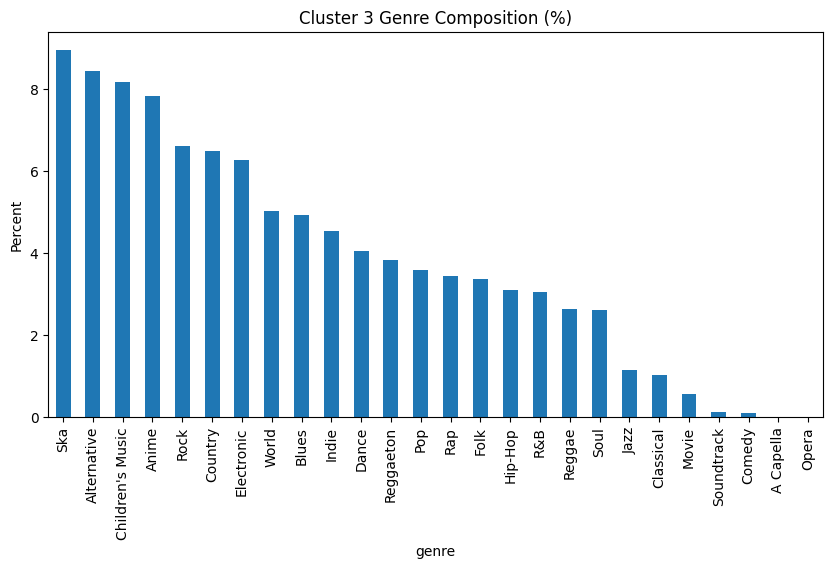

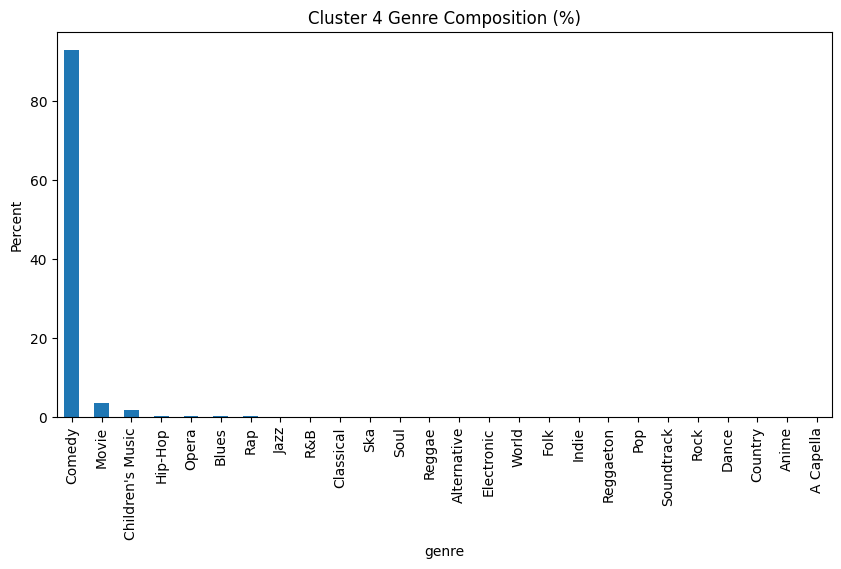

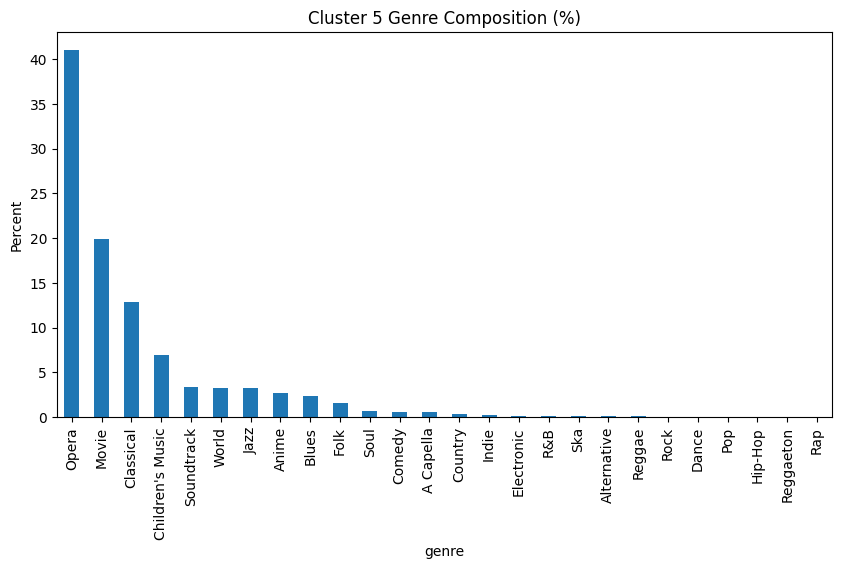

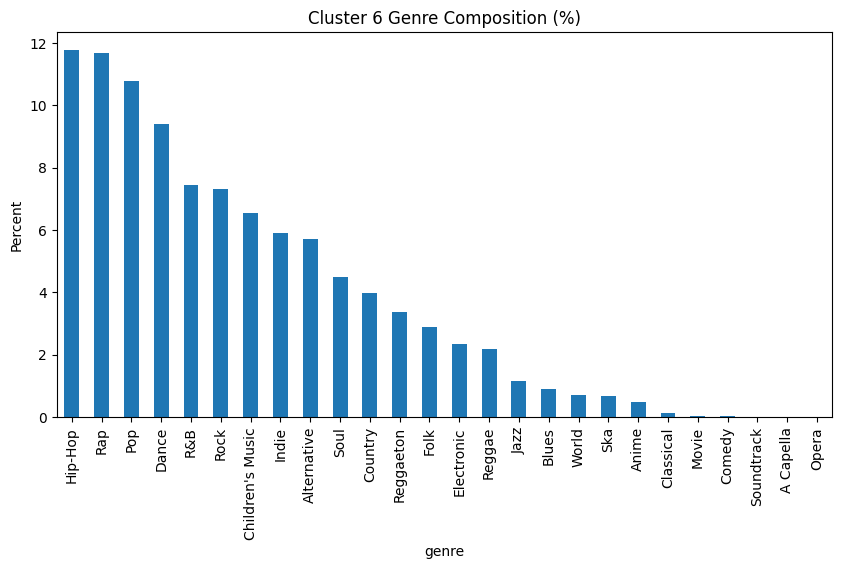

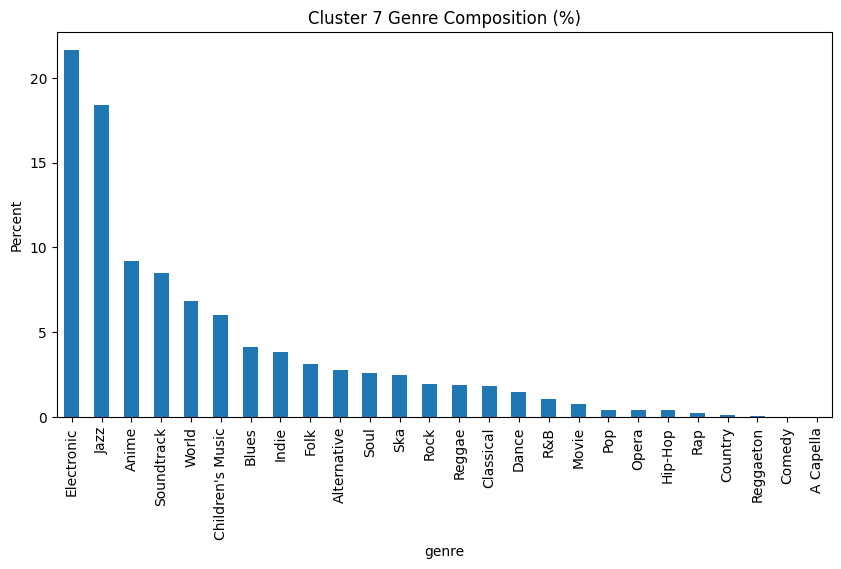

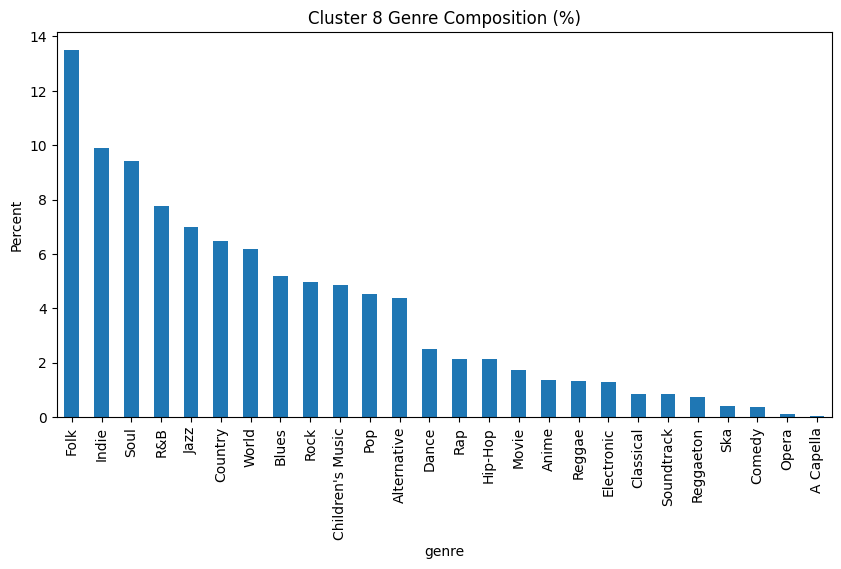

In [ ]:
genre_pct = pd.crosstab(df["cluster"], df["genre"], normalize="index") * 100

for c in sorted(df["cluster"].unique()):
    genre_pct.loc[c].sort_values(ascending=False).plot(
        kind="bar",
        title=f"Cluster {c} Genre Composition (%)",
        figsize=(10, 5)
    )
    plt.ylabel("Percent")
    plt.show()

**Mode Breakdown**

In [ ]:
pd.set_option("display.max_columns", None)
display(pd.crosstab(df["cluster"], df["mode"], normalize="index"))

mode,0,1
cluster,,
0,0.618772,0.381228
1,0.663533,0.336467
2,0.660623,0.339377
3,0.671250,0.328750
4,0.681464,0.318536
5,0.758402,0.241598
6,0.601217,0.398783
7,0.573606,0.426394
8,0.703369,0.296631


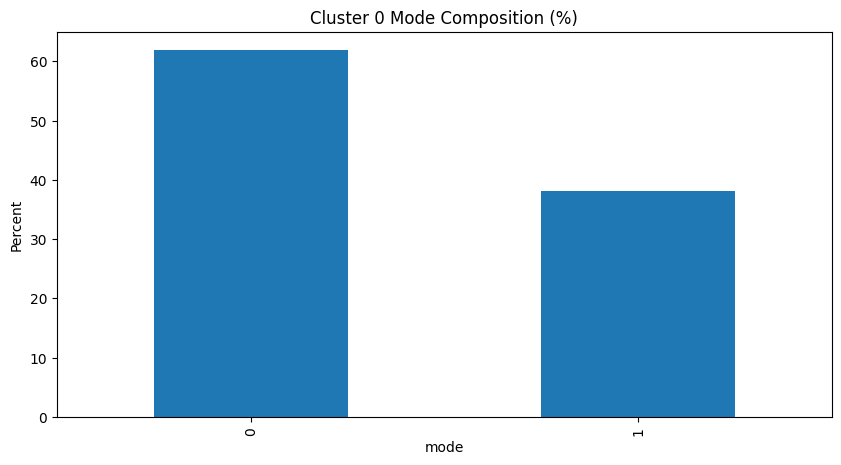

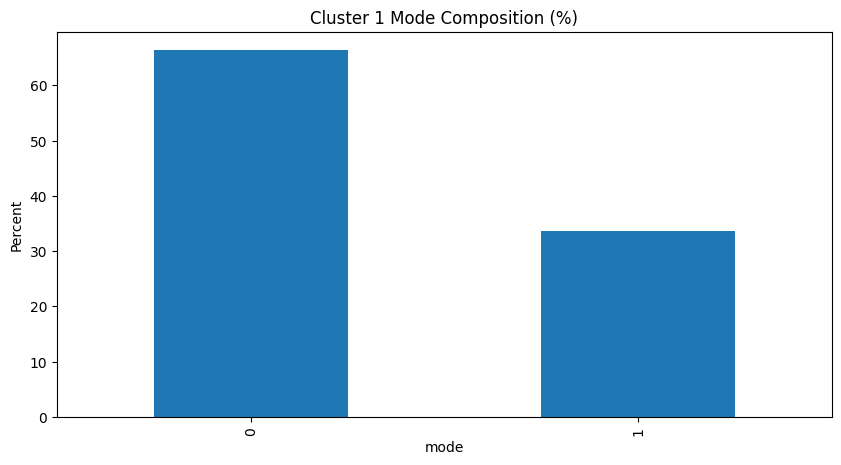

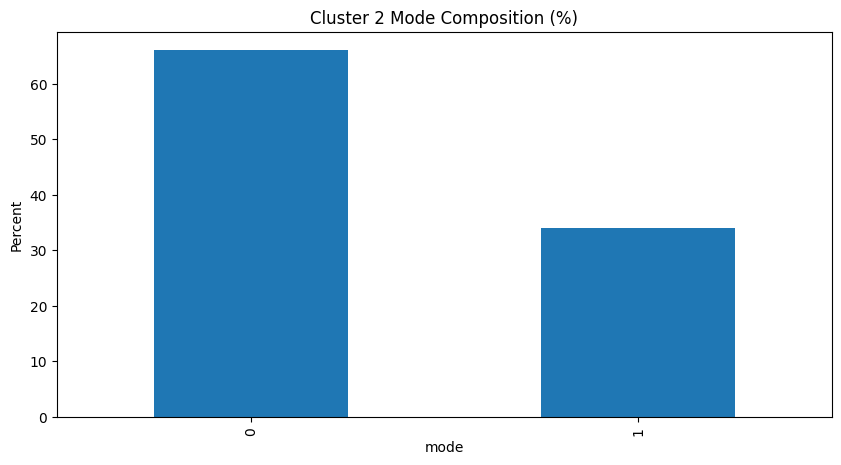

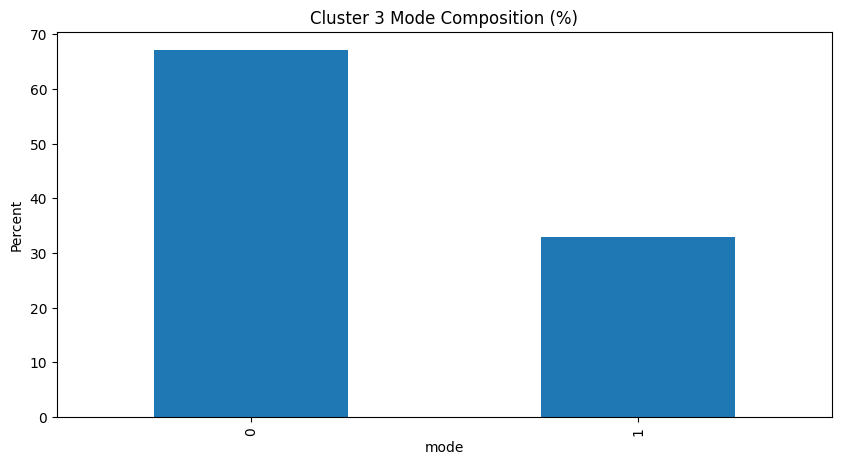

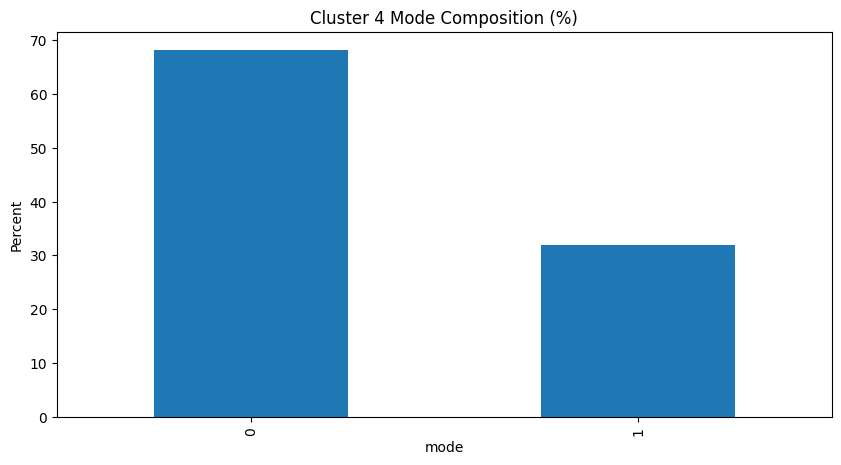

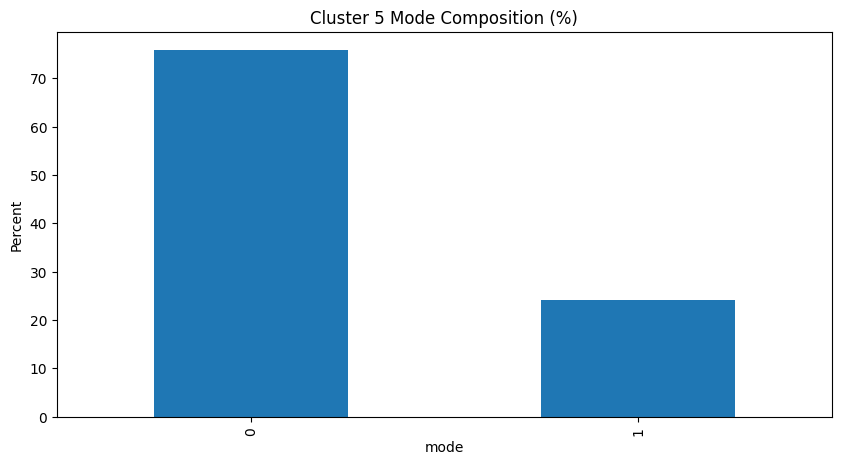

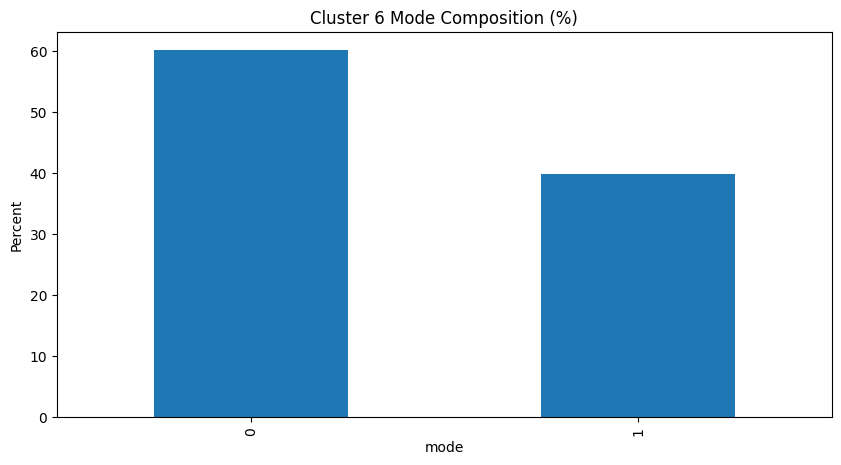

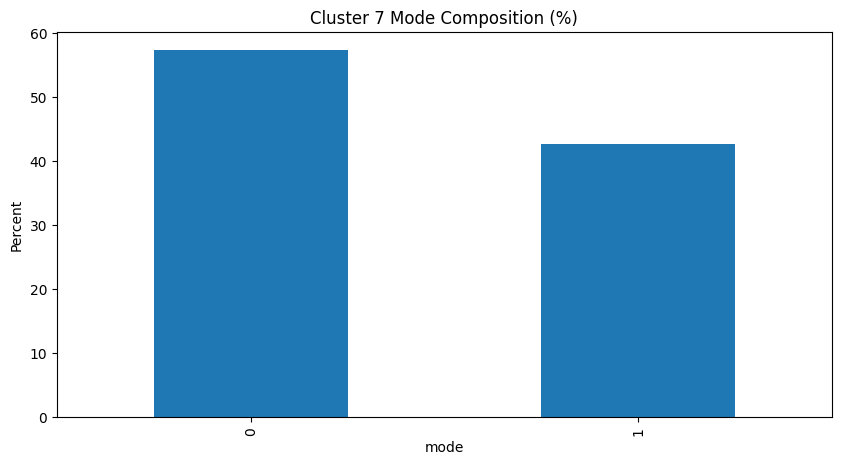

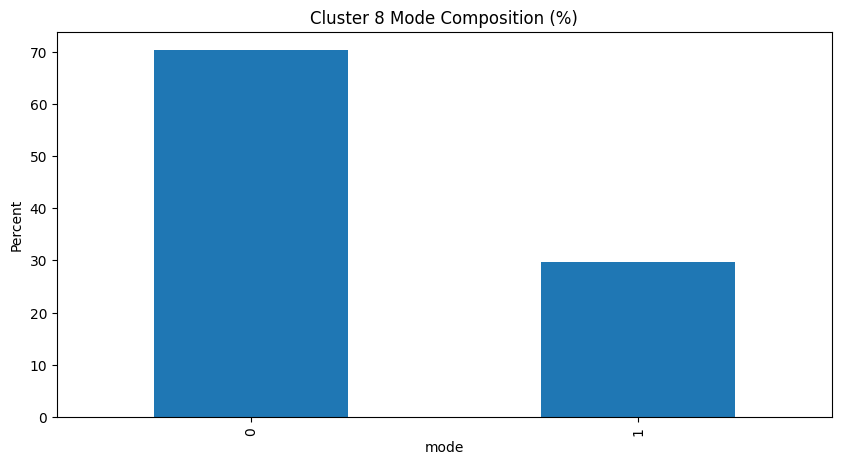

In [ ]:
mode_pct = pd.crosstab(df["cluster"], df["mode"], normalize="index") * 100

for c in sorted(df["cluster"].unique()):
    mode_pct.loc[c].sort_values(ascending=False).plot(
        kind="bar",
        title=f"Cluster {c} Mode Composition (%)",
        figsize=(10, 5)
    )
    plt.ylabel("Percent")
    plt.show()

**Key Breakdown**

In [ ]:
pd.set_option("display.max_columns", None)
display(pd.crosstab(df["cluster"], df["key"], normalize="index"))

key,A,A#,B,C,C#,D,D#,E,F,F#,G,G#
cluster,,,,,,,,,,,,
0,0.099889,0.068056,0.044904,0.139874,0.064245,0.129359,0.052718,0.078763,0.106063,0.039020,0.130372,0.046737
1,0.108991,0.070224,0.076829,0.125948,0.084201,0.097564,0.025466,0.069517,0.089208,0.059411,0.129850,0.062790
2,0.105067,0.056880,0.090578,0.126014,0.093145,0.102832,0.020285,0.085196,0.077082,0.063007,0.131893,0.048021
3,0.102758,0.050983,0.087822,0.115371,0.102072,0.110727,0.028816,0.080486,0.071962,0.069534,0.112284,0.067186
4,0.082530,0.087144,0.068075,0.057515,0.156141,0.091142,0.043572,0.074431,0.084991,0.129280,0.063564,0.061616
5,0.086695,0.082866,0.043909,0.130076,0.070320,0.111390,0.056388,0.074612,0.113635,0.045560,0.117531,0.067019
6,0.087657,0.070232,0.089780,0.106710,0.133246,0.090488,0.021936,0.064836,0.081802,0.075327,0.098785,0.079201
7,0.100187,0.072864,0.073639,0.111685,0.097733,0.109295,0.025128,0.076739,0.092436,0.058200,0.123442,0.058653
8,0.100279,0.061642,0.069505,0.135047,0.076845,0.104364,0.042968,0.083111,0.089468,0.060598,0.114162,0.062011


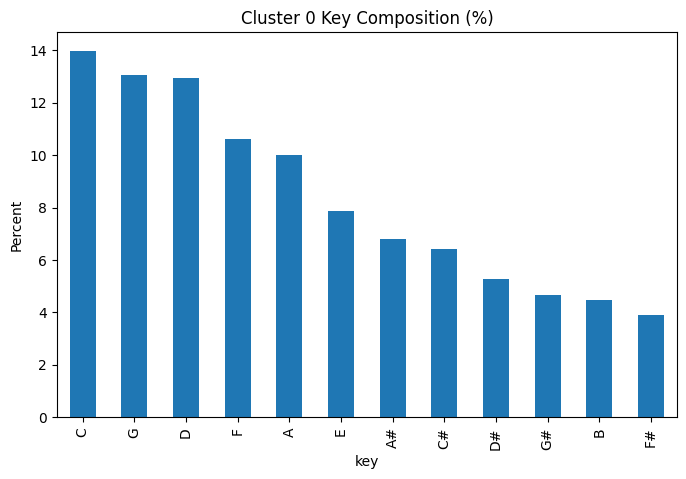

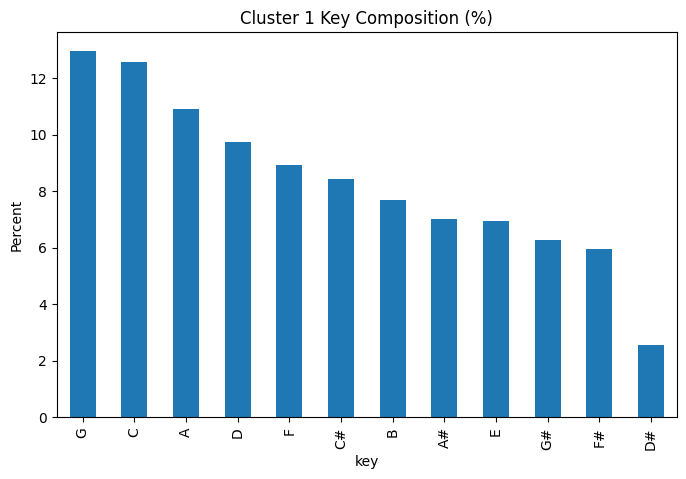

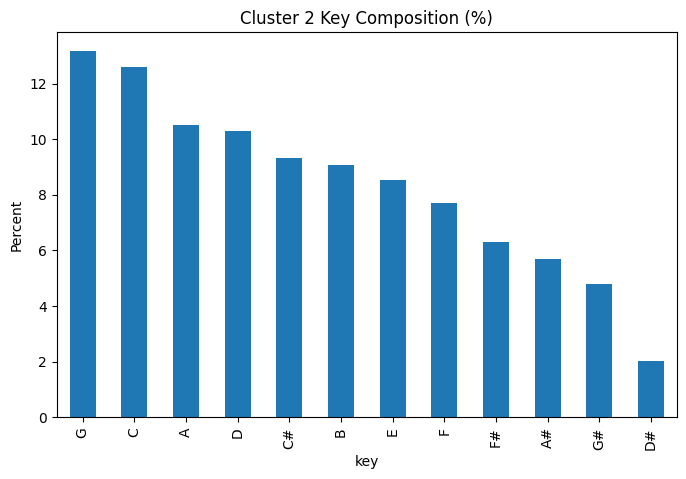

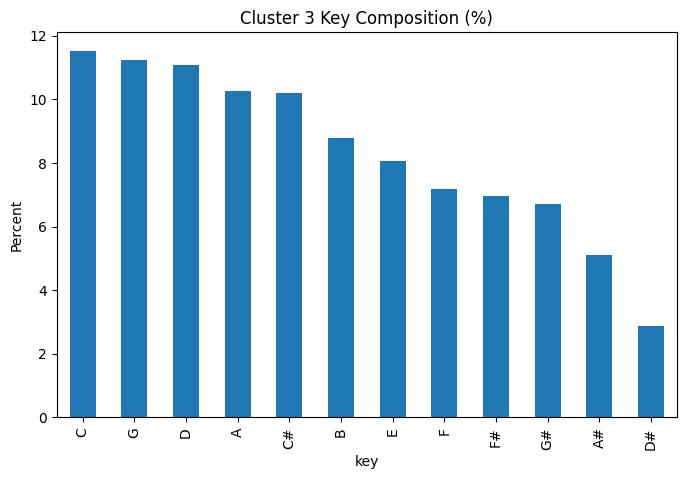

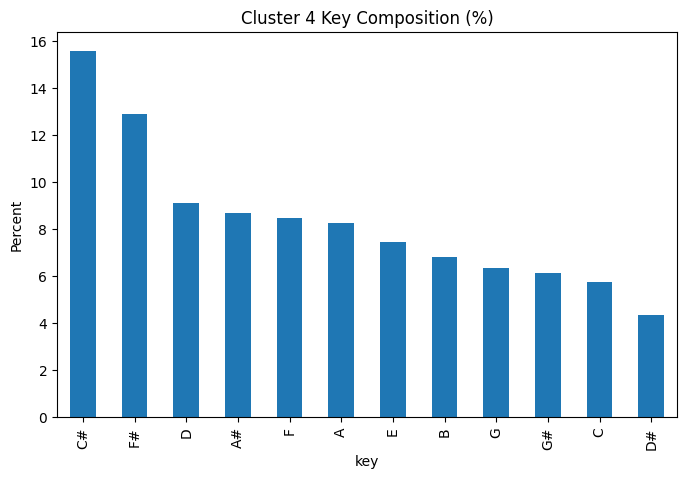

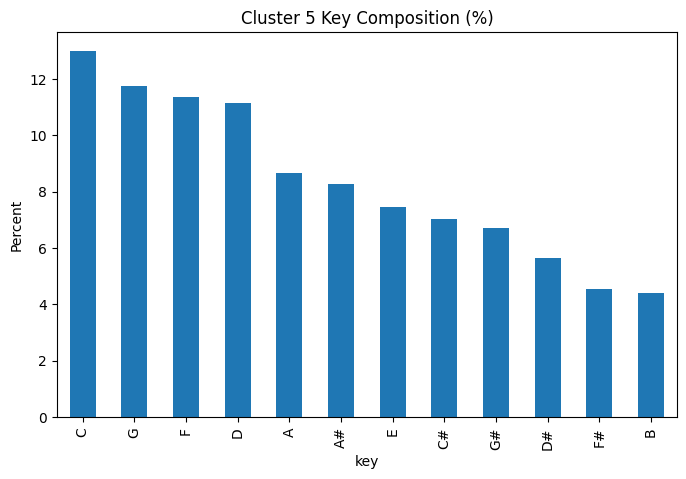

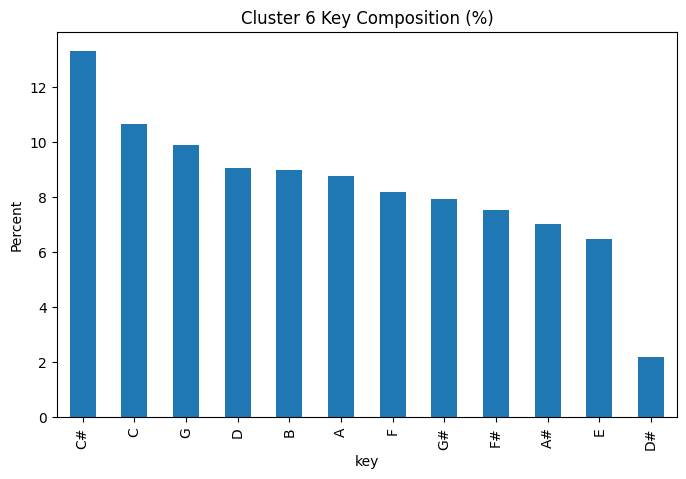

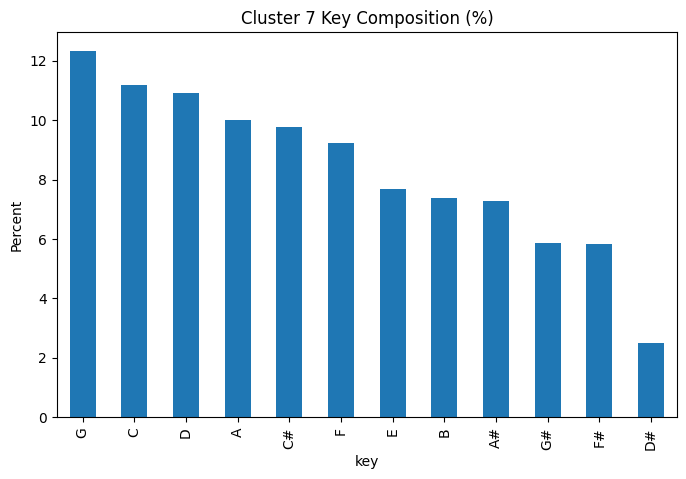

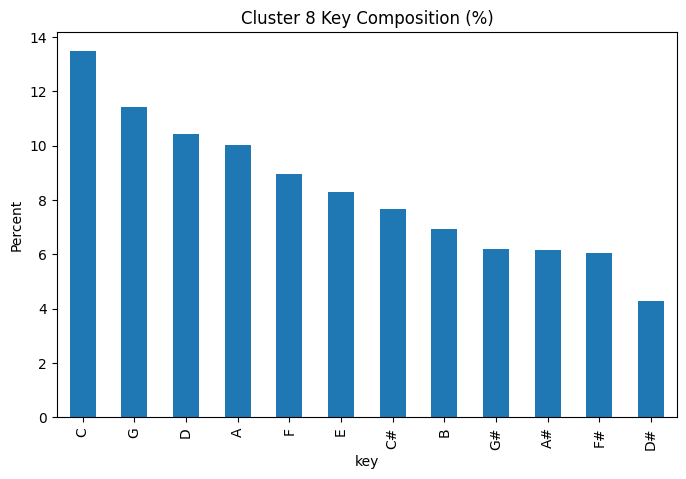

In [ ]:
key_pct = pd.crosstab(df["cluster"], df["key"], normalize="index") * 100

for c in sorted(df["cluster"].unique()):
    key_pct.loc[c].sort_values(ascending=False).plot(
        kind="bar",
        title=f"Cluster {c} Key Composition (%)",
        figsize=(8, 5)
    )
    plt.ylabel("Percent")
    plt.show()

**Time Signature Breakdown**

In [ ]:
pd.set_option("display.max_columns", None)
display(pd.crosstab(df["cluster"], df["time_signature"], normalize="index"))

time_signature,0/4,1/4,3/4,4/4,5/4
cluster,,,,,
0,0.000096,0.030676,0.276853,0.637245,0.055130
1,0.000000,0.003195,0.028047,0.961355,0.007403
2,0.000000,0.005547,0.054065,0.929707,0.010681
3,0.000000,0.002058,0.064600,0.925188,0.008154
4,0.000103,0.058643,0.361493,0.468013,0.111749
5,0.000132,0.037966,0.291383,0.607593,0.062925
6,0.000053,0.002176,0.016965,0.970510,0.010296
7,0.000000,0.009043,0.076093,0.903882,0.010981
8,0.000000,0.009613,0.131484,0.839829,0.019073


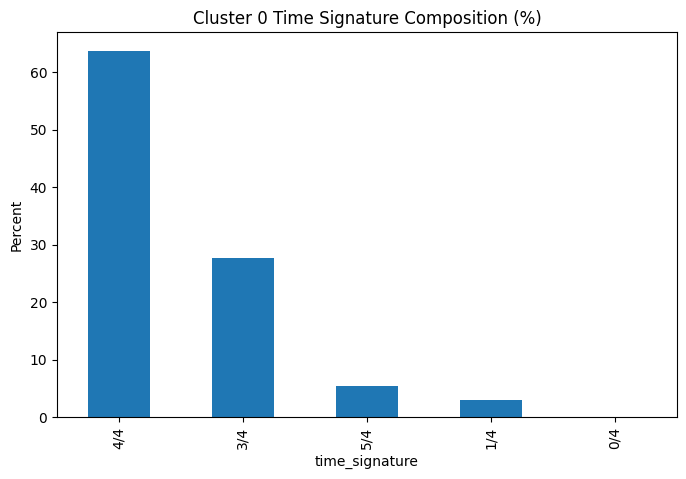

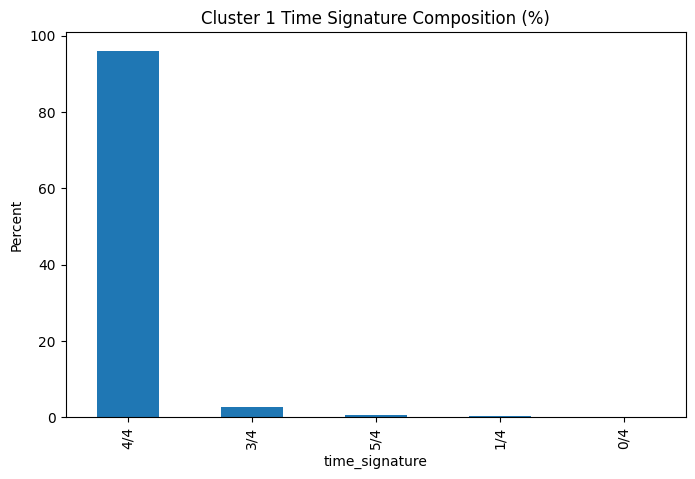

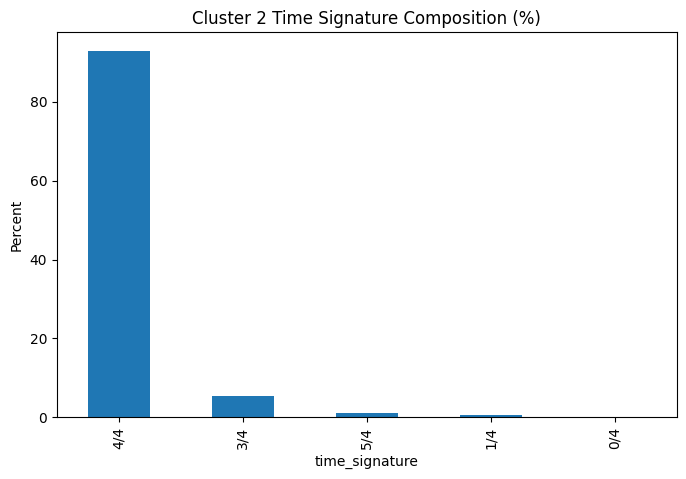

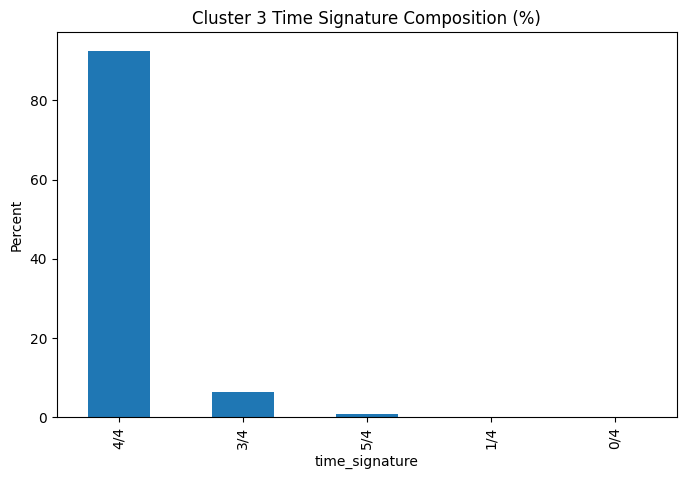

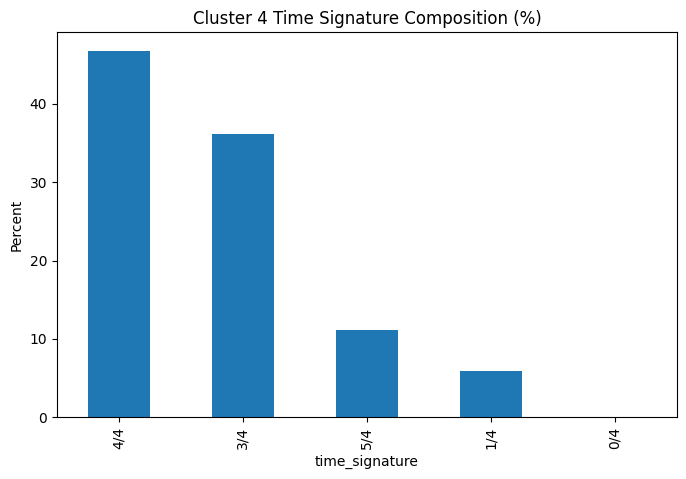

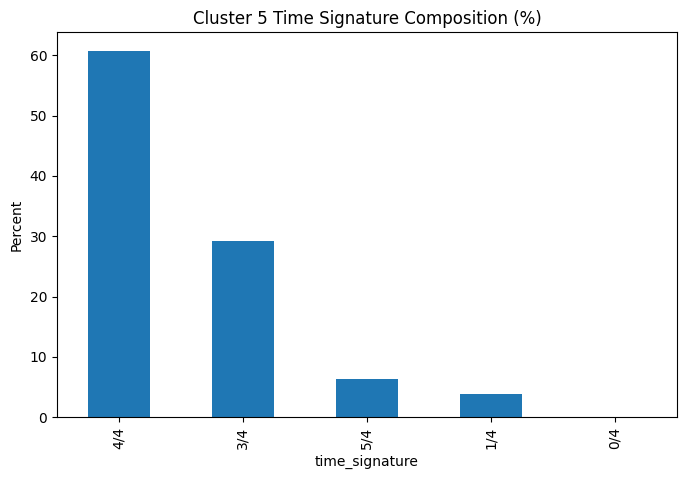

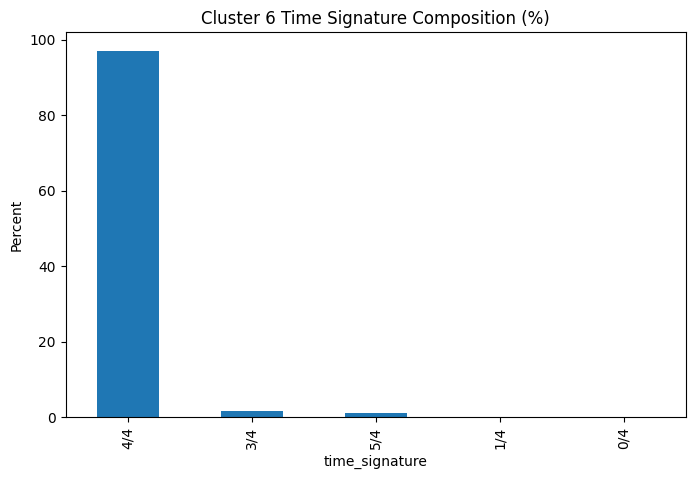

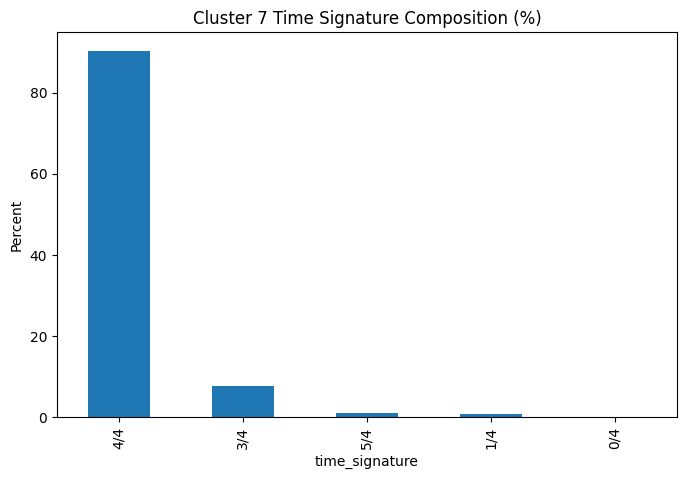

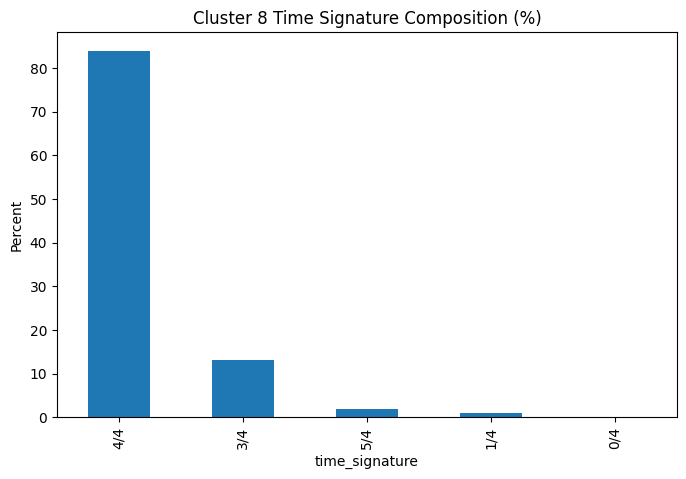

In [ ]:
ts_pct = pd.crosstab(df["cluster"], df["time_signature"], normalize="index") * 100

for c in sorted(df["cluster"].unique()):
    ts_pct.loc[c].sort_values(ascending=False).plot(
        kind="bar",
        title=f"Cluster {c} Time Signature Composition (%)",
        figsize=(8, 5)
    )
    plt.ylabel("Percent")
    plt.show()

**Feature Averages per Cluster**

In [ ]:
cluster_summary = df.groupby("cluster")[[
    "popularity", "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "loudness",
    "speechiness", "tempo", "valence"
]].mean()

print(cluster_summary)

         popularity  acousticness  danceability    energy  instrumentalness  \
cluster                                                                       
0         29.919934      0.872526      0.275217  0.142666          0.841136   
1         28.415722      0.269675      0.700390  0.661981          0.022772   
2         41.310151      0.208953      0.538674  0.726520          0.054304   
3         44.658398      0.093576      0.483520  0.782699          0.025389   
4         20.519787      0.801432      0.562909  0.665713          0.000510   
5         15.952658      0.899274      0.356334  0.178625          0.056663   
6         57.342438      0.134260      0.680609  0.687994          0.013708   
7         36.294296      0.282346      0.571446  0.607045          0.781126   
8         48.826930      0.596998      0.536653  0.382288          0.030228   

         liveness   loudness  speechiness       tempo   valence  
cluster                                                         

**Overall Feature Averages**

In [ ]:
overall_mean = df[[
    "popularity", "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "loudness",
    "speechiness", "tempo", "valence"
]].mean()

print(overall_mean)

popularity           41.127502
acousticness          0.368560
danceability          0.554364
energy                0.570958
instrumentalness      0.148301
liveness              0.215009
loudness             -9.569885
speechiness           0.120765
tempo               117.666585
valence               0.454917
dtype: float64


**Differences between each cluster's trait and the overall mean of that trait**

In [ ]:
cluster_diff = cluster_summary - overall_mean
print(cluster_diff)

         popularity  acousticness  danceability    energy  instrumentalness  \
cluster                                                                       
0        -11.207568      0.503965     -0.279148 -0.428291          0.692835   
1        -12.711780     -0.098886      0.146025  0.091023         -0.125530   
2          0.182648     -0.159607     -0.015691  0.155563         -0.093997   
3          3.530896     -0.274985     -0.070844  0.211741         -0.122912   
4        -20.607716      0.432872      0.008545  0.094755         -0.147791   
5        -25.174845      0.530714     -0.198031 -0.392333         -0.091638   
6         16.214936     -0.234300      0.126245  0.117037         -0.134593   
7         -4.833206     -0.086215      0.017082  0.036087          0.632825   
8          7.699427      0.228438     -0.017712 -0.188670         -0.118073   

         liveness   loudness  speechiness      tempo   valence  
cluster                                                         


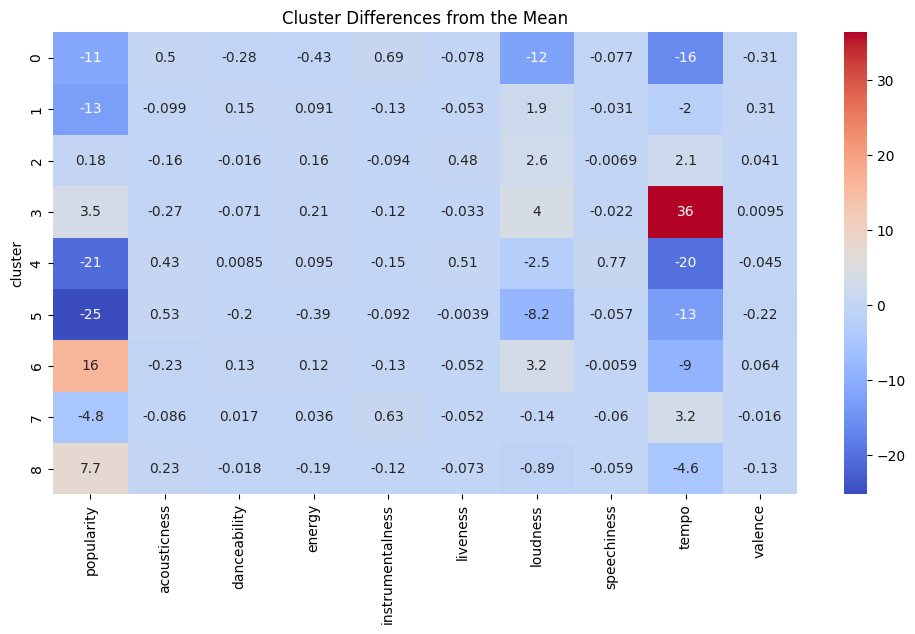

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_diff, cmap="coolwarm", annot=True)
plt.title("Cluster Differences from the Mean")
plt.show()

Cluster 3 had a markedly different tempo, Cluster 5 had a markedly different popularity, and Cluster 4 had a markedly different popularity and tempo.

**How numerical features of each cluster compare to the overall mean, as measured by scaled z-scores.**

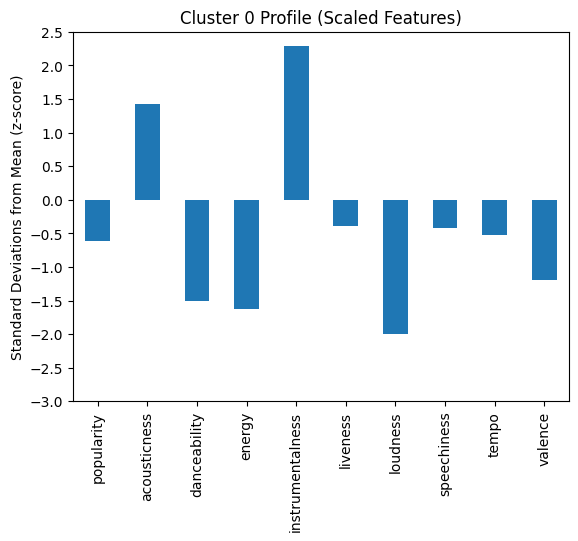

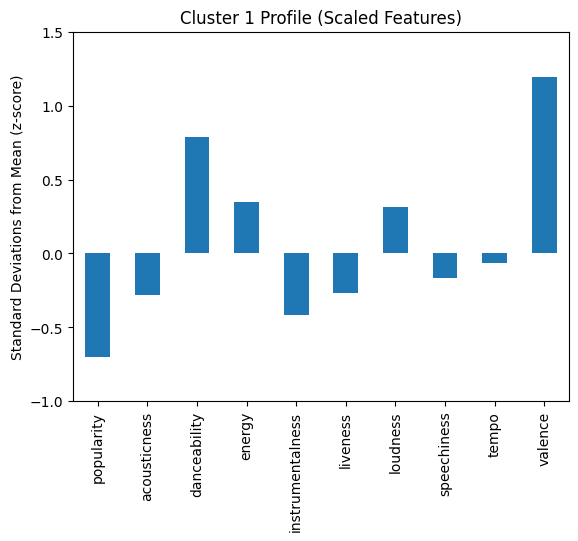

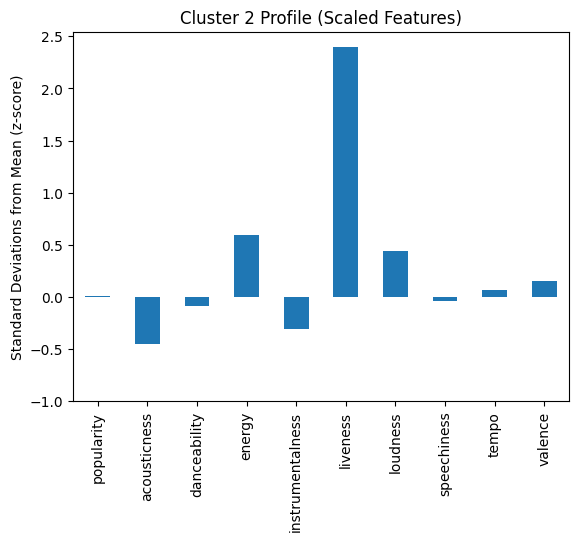

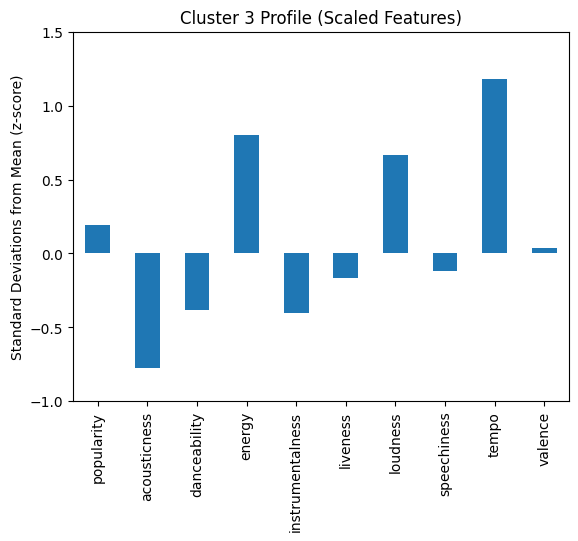

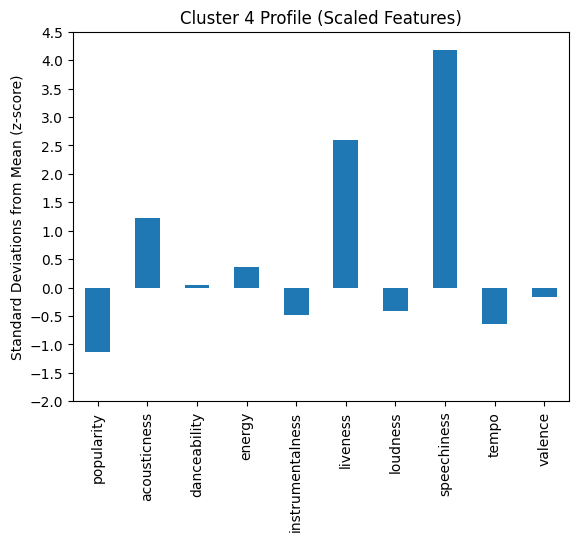

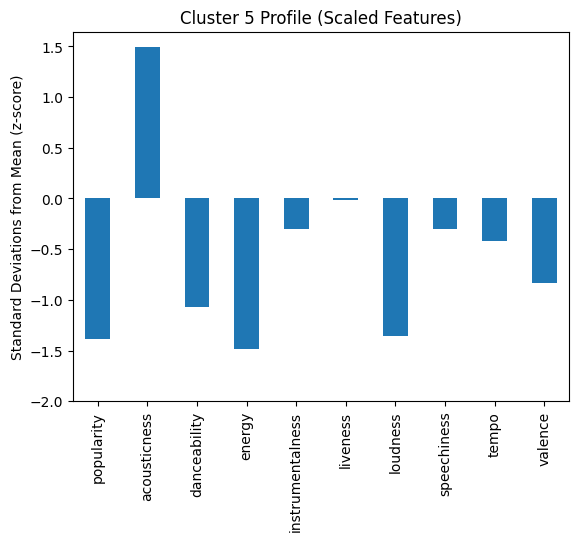

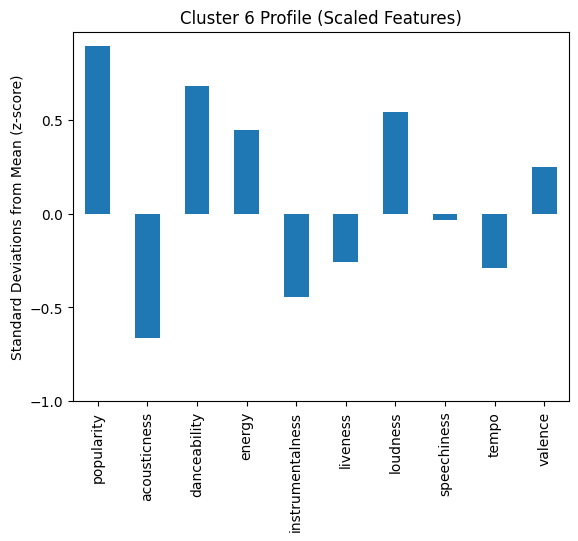

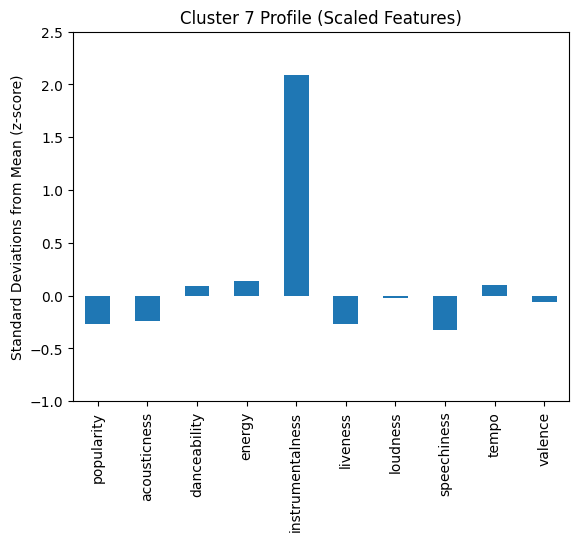

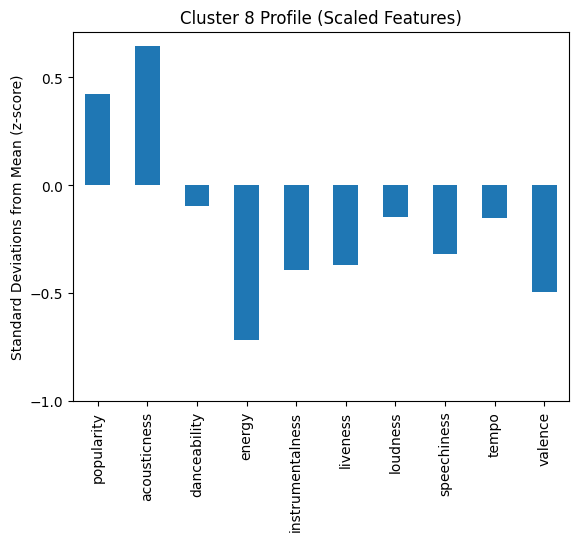

In [ ]:
num_cols = [
    "popularity", "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "loudness",
    "speechiness", "tempo", "valence"
]

x_num_scaled_df = pd.DataFrame(x_num_scaled, columns=num_cols, index=df.index)
x_num_scaled_df["cluster"] = km.labels_

cluster_summary_scaled = x_num_scaled_df.groupby("cluster")[num_cols].mean()

for i in range(len(cluster_summary_scaled)):
    ax = cluster_summary_scaled.loc[i].plot(
        kind="bar",
        title=f"Cluster {i} Profile (Scaled Features)"
    )
    ymin, ymax = ax.get_ylim()
    ax.set_yticks(np.arange(np.floor(ymin), np.ceil(ymax), 0.5))
    plt.ylabel("Standard Deviations from Mean (z-score)")
    plt.show()

**Playlist Formation**

Get each song's distance from its own centroid

In [ ]:
distances = np.empty(len(df))

for c in range(km.n_clusters):
    cluster_mask = (df["cluster"] == c).values
    cluster_points = x_final[cluster_mask]
    centroid = km.cluster_centers_[c]
    distances[cluster_mask] = np.linalg.norm(cluster_points - centroid, axis=1)

df["distance_to_centroid"] = distances

Get the top 20 songs per cluster

In [ ]:
playlist_candidates = (
    df.sort_values(["cluster", "distance_to_centroid"])
      .groupby("cluster")
      .head(20)
      .copy()
)

Streamline features

In [ ]:
playlist_lists = playlist_candidates[[
    "cluster", "track_name", "artist_name", "genre", "distance_to_centroid"
]].sort_values(["cluster", "distance_to_centroid"])

Full playlists

In [ ]:
playlist_lists[playlist_lists["cluster"] == 0]

,cluster,track_name,artist_name,genre,distance_to_centroid
206648,0,Meaning of Life,Ramin Djawadi,Soundtrack,0.983881
205963,0,Thin Ice,Gustavo Santaolalla,Soundtrack,1.009795
130849,0,"Symphony No. 6 in F Major, Op. 68 ""Pastoral"": ...",Ludwig van Beethoven,Classical,1.034251
204677,0,It Was Me,John Powell,Soundtrack,1.038982
205674,0,The Marriage - Finding Neverland/Soundtrack Ve...,Jan A.P. Kaczmarek,Soundtrack,1.042635
129643,0,"Sonata No. 1 in F Minor, Op. 2 No. 1: IV. Pres...",Ludwig van Beethoven,Classical,1.046555
125981,0,"Symphony No. 3 in C Minor, Op. 78, R. 176 ""Org...",Camille Saint-Saëns,Classical,1.046791
130044,0,"String Quartet No. 12 in F Major, Op. 96, B. 1...",Antonín Dvořák,Classical,1.059768
202944,0,Midnight in the Garden,Atli Örvarsson,Soundtrack,1.060118
204403,0,A Homeward Bound Overture - Score Version,Bruce Broughton,Soundtrack,1.062420


In [ ]:
playlist_lists[playlist_lists["cluster"] == 1]

,cluster,track_name,artist_name,genre,distance_to_centroid
166034,1,Poetico,Jadiel el Incomparable,Reggaeton,1.021751
52180,1,Sweet Goddess of Love and Beer,Popa Chubby,Blues,1.073847
49723,1,Grits Ain't Groceries (All Around The World),Little Milton,Blues,1.076847
186481,1,Your Guts (I Hate 'Em) - Dirty Version,Reel Big Fish,Ska,1.094842
134902,1,I'm Not Ashamed / Under Tight Wraps (feat. I Roy),Culture,Reggae,1.101714
53871,1,Easy On My Soul - Previously Unreleased Version,Bad Company,Blues,1.117367
132996,1,One By One,The Black Seeds,Reggae,1.124701
136068,1,"Scarlet Begonias - 1994/Live On KUCI, Irvine",Sublime,Reggae,1.131966
50471,1,Right Down The Line,Bonnie Raitt,Blues,1.133319
135409,1,Kiss And Tell,G. Love & Special Sauce,Reggae,1.134973


In [ ]:
playlist_lists[playlist_lists["cluster"] == 2]

,cluster,track_name,artist_name,genre,distance_to_centroid
84467,2,Something About The Name Jesus Pt. 2,Kirk Franklin,R&B,1.286812
85229,2,Gradient,Choker,R&B,1.288288
44967,2,Stolen Car,Beth Orton,Folk,1.294275
47118,2,The Lost Art Of Keeping A Secret,Queens of the Stone Age,Blues,1.325271
717,2,Playing The Part,Jamey Johnson,Country,1.329552
20792,2,The Fool,Ryn Weaver,Dance,1.336217
12250,2,Heaven Beside You - Live at the Majestic Theat...,Alice In Chains,Alternative,1.339249
132012,2,Feeling Alright - Live,Rebelution,Reggae,1.341310
7106,2,Sunshine,Ryan Bingham,Country,1.342124
23824,2,Beautiful,What So Not,Electronic,1.350089


In [ ]:
playlist_lists[playlist_lists["cluster"] == 3]

,cluster,track_name,artist_name,genre,distance_to_centroid
9375,3,City On Our Knees,TobyMac,Alternative,1.032723
216425,3,Unstoppable,Rascal Flatts,Country,1.085565
99545,3,City On Our Knees,TobyMac,Children's Music,1.089981
215159,3,Pick-Up Lines,Justin Moore,Country,1.090462
143643,3,New Machines,Vinyl Theatre,Indie,1.099915
12261,3,Feelin' Way Too Damn Good,Nickelback,Alternative,1.102659
84836,3,What You Want,Stefflon Don,R&B,1.103258
3686,3,You Think You Know Somebody,Hunter Hayes,Country,1.105924
103667,3,Feelin' Way Too Damn Good,Nickelback,Children's Music,1.108857
216293,3,Out There,Chris Janson,Country,1.114623


In [ ]:
playlist_lists[playlist_lists["cluster"] == 4]

,cluster,track_name,artist_name,genre,distance_to_centroid
170183,4,Chicken Dance/YMCA,Russell Peters,Comedy,0.859662
171264,4,Sex With A Fat Girl,Brad Williams,Comedy,0.873585
174388,4,Mariposa de Barrio,Alan Saldaña,Comedy,0.901727
173880,4,Dice On Nutrition - Live At Govenors/1991,Andrew Dice Clay,Comedy,0.913095
171326,4,My S****y Limp Dick,Jim Norton,Comedy,0.913216
172027,4,Allergies,Louis Katz,Comedy,0.913399
172688,4,The Nipple Flicker,Jim Norton,Comedy,0.938092
171105,4,Eharmony is Petrifying,Andrew Norelli,Comedy,0.941465
169393,4,Gambling,Dave Attell,Comedy,0.942989
171300,4,Taylor Dayne,Tig Notaro,Comedy,0.944591


In [ ]:
playlist_lists[playlist_lists["cluster"] == 5]

,cluster,track_name,artist_name,genre,distance_to_centroid
81759,5,O coeli devota (Motetti sacri a voce sola con ...,Philippe Jaroussky,Opera,0.948624
59206,5,"Roméo et Juliette / Act 2: ""Ah! ne fuis pas en...",Charles Gounod,Opera,0.983382
82749,5,"Tosca, S. 69, Act II: Meno male!",Giacomo Puccini,Opera,0.995022
82111,5,"Aida: Ma, dimmi: per qual via",Giuseppe Verdi,Opera,1.013276
81318,5,Madama Butterfly - Act I: Questa è la cameriera,Giacomo Puccini,Opera,1.019466
107643,5,"Vert-Vert, Acte II Scènes 7B & C: Air de la Co...",Jacques Offenbach,Opera,1.025168
58690,5,"La traviata, Act 1: ""Libiamo ne'lieti calici (...",Giuseppe Verdi,Opera,1.042008
83101,5,"Bizet: Carmen, Act 1: ""Sur la place"" (Chorus, ...",Georges Bizet,Opera,1.054657
105332,5,"Rameau: Platée, Act 2: ""Aux langueurs d'Apollon""",Jean-Philippe Rameau,Opera,1.059508
82203,5,"Tosca, S. 69, Act I: Tutto è chiaro...Tosca? C...",Giacomo Puccini,Opera,1.061613


In [ ]:
playlist_lists[playlist_lists["cluster"] == 6]

,cluster,track_name,artist_name,genre,distance_to_centroid
18403,6,Come Alive - Bonus Track,Craig David,Dance,1.009873
60416,6,Come Alive - Bonus Track,Craig David,R&B,1.028812
18801,6,Nostalgia - Single Version,MØ,Dance,1.040142
226628,6,Come Alive - Bonus Track,Craig David,Soul,1.057162
121319,6,Back To The Start,SoMo,Rap,1.087695
151594,6,Back To The Start,SoMo,Pop,1.096041
120123,6,The Wonder Years,Jon Bellion,Rap,1.098338
154703,6,Who Do You Love,Marianas Trench,Rock,1.102608
121913,6,Make Me... (feat. G-Eazy),Britney Spears,Rap,1.106994
90591,6,Miss You Bad,Mr Eazi,Hip-Hop,1.108649


In [ ]:
playlist_lists[playlist_lists["cluster"] == 7]

,cluster,track_name,artist_name,genre,distance_to_centroid
38450,7,Fever,Télépopmusik,Electronic,1.097326
177929,7,Lazy Place,Caravan Palace,Jazz,1.102090
149007,7,Two For Bleu,Charlie Hunter,Jazz,1.159601
38503,7,Age Well,Ten Walls,Electronic,1.164996
40422,7,Ночной визит,Luna,Electronic,1.170024
37514,7,Little Words,Mint Royale,Electronic,1.178939
176383,7,The Crossing,Acoustic Alchemy,Jazz,1.186262
29858,7,Attack of the WEAPON,Nobuo Uematsu,Anime,1.218929
39788,7,Journey Inwards,LTJ Bukem,Electronic,1.219193
148798,7,Yèkèrmo Sèw,Mulatu Astatke,Jazz,1.221990


In [ ]:
playlist_lists[playlist_lists["cluster"] == 8]

,cluster,track_name,artist_name,genre,distance_to_centroid
65532,8,As We Go Along,The Monkees,Folk,1.053623
64255,8,Eagles and Horses,John Denver,Folk,1.061370
64101,8,With You,Jacob Lee,Folk,1.061935
63062,8,Meteor Showers,Andy Kong,Folk,1.078222
145042,8,Meteor Showers,Andy Kong,Indie,1.111073
43171,8,Passionfruit (triple j Like A Version),Angus & Julia Stone,Folk,1.111941
43332,8,Morning,Beck,Folk,1.116553
227956,8,U,Alex Lustig,Soul,1.116835
64743,8,When The Roses Bloom Again,Billy Bragg,Folk,1.118290
65250,8,New Day,Tom Speight,Folk,1.118683


**Profile Analysis Language**:

In the below recaps of each cluster, I will use the following language:

-- "Strikingly high" = 2 standard deviations from the mean

-- "High" = 1.5 standard deviations

-- "Low" = -1.5 standard deviations

-- "Strikingly low" = -2 standard deviations

**Compared to the average, what makes Cluster 0 special?**

-- It has a low share of total songs at 9 percent.

-- Its most common genres are soundtrack at 36 percent and classical at 30 percent.

-- Its time signature breakdown is more varied than the average, with 64 percent 4/4 and 28 percent 3/4.

-- It has strikingly high instrumentalness, high acousticness, low danceability, low energy, low valence, and strikingly low loudness.

-- Playlist: https://open.spotify.com/playlist/0jpgb4RmXags0rMTPJynkY

**Compared to the average, what makes Cluster 1 special?**

-- Its most common genres are reggae at 16 percent, reggaeton at 14 percent, and ska at 11 percent.

-- It has high valence.

-- Playlist: https://open.spotify.com/playlist/2baIniOscFQQoM93pjyvTF

**Compared to the average, what makes Cluster 2 special?**

-- It has a very low share of total songs at 5 percent.

-- Its most common genres are world at 10 percent, blues at 9 percent, ska at 9 percent, and electronic at 6 percent.

-- It has strikingly high liveness.

-- Playlist: https://open.spotify.com/playlist/0ORlWRhMOdXMHSeZ8FythG

**Compared to the average, what makes Cluster 3 special?**

-- Its most common genres are ska at 9 percent, alternative at 8 percent, children's music at 8 percent, anime at 8 percent, rock at 7 percent, country at 6 percent, and electronic at 6 percent.

-- It has high tempo.

-- Playlist: https://open.spotify.com/playlist/1SGq6SFAjx9ujUzZTAaK34

**Compared to the average, what makes Cluster 4 special?**

-- It's not songs, rather spoken standup comedy vignettes.

-- It has a very low share of the total data at 4 percent.

-- Its most common genre is comedy at 93 percent.

-- The key of F# is unusually common at 13 percent.

-- Its time signature breakdown is more varied than the average, with 47 percent 4/4 and 36 percent 3/4, due to the relatively irregular rhythm of spoken words.

-- It has strikingly high speechiness and liveness, high acousticness (from the absence of electronic signatures), and low popularity (most people don't go on Spotify to listen to comedy albums).

-- Playlist: https://open.spotify.com/playlist/210DW6LMBjbWpHIozbHAFm

**Compared to the average, what makes Cluster 5 special?**

-- It has a low share of total songs at 7 percent.

-- Its most common genre is opera at 41 percent.

-- Its major-minor mode breakdown leans more toward major than the average, with 76 percent major and 24 percent minor.

-- The key of F is unusually common with 11 percent of songs.

-- Its time signature breakdown is more varied than the average, with 61 percent 4/4 and 29 percent 3/4.

-- It has high acousticness, low popularity, low danceability, low energy, and low loudness.

-- Playlist: https://open.spotify.com/playlist/4MoLBzmxSTUIwLoR80LYqm

**Compared to the average, what makes Cluster 6 special?**

-- It has a high share of total songs at 24 percent.

-- Its most common genres are hip hop at 12 percent, rap at 12 percent, pop at 11 percent, and dance at 9 percent.

-- Playlist: https://open.spotify.com/playlist/3wRZ1nnl4RK8rxeAR4WEJ9

**Compared to the average, what makes Cluster 7 special?**

-- It has a low share of songs at 7 percent.

-- Its most common genres are electronic at 22 percent and jazz at 18 percent.

-- Its major-minor mode breakdown leans more toward minor than average, with 57 percent major and 43 percent minor.

-- It has strikingly high instrumentalness.

-- Playlist: https://open.spotify.com/playlist/6pTnnEjYy2m1f0xw2MZn28

**Compared to the average, what makes Cluster 8 special?**

-- Its most common genres are folk at 13 percent, indie at 10 percent, and soul at 9 percent.

-- Playlist: https://open.spotify.com/playlist/2PDimzcPU5XWxrSjyfYooR

**Cluster Differences from the Mean**

-- Z-score ranges were assessed by using the total range of the y-axis.

-- Cluster 4 and Cluster 0 were spread the farthest from the mean, with z-score ranges of 6.5 and 5.5 respectively (i.e., Cluster 4 ranges from -2 to 4.5).

-- Cluster 6 and Cluster 8 were spread the least, with a z-score range of 1.5.

**Which Features Mattered Most?**

-- Maximum z-score was assessed by evaluating each feature's z-score in each cluster and selecting the z-score farthest from the mean.

-- Speechiness, with a maximum z-score of 4, had the most pronounced impact on group formation far from the overall mean.

-- Instrumentalness and liveness, with a maximum z-score of 2.5, had a high impact.

-- Loudness, with a maximum z-score of 2, had a significant impact.

**Conclusion**

**Average versus Niche**

-- Clusters 6 and 8 most matched the overall song profile, with z-score ranges of 1.5. With a combined 55 percent of all songs, they indicated the kinds of songs most common on Spotify. The most common genres in these clusters were hip hop, rap, pop, dance, folk, indie, and soul. Clusters 6 and 8 had the greatest popularity, with z-scores of 1 and 0.5. The features that most united Clusters 6 and 8, as measured by z-score differences, were lower-than-average instrumentalness, tempo, liveness, and speechiness.

-- Clusters 4 and 0 were the most niche, with z-score ranges of 6.5 and 5.5. Combined, they comprised 13 percent of all songs. The most common genres in these clusters were comedy, soundtrack, and classical. The features that most united Clusters 4 and 0, as measured by z-score differences, were lower-than average tempo, popularity, and valence and higher-than-average acousticness.

**Counterintuitive Genre Pairings**

-- Cluster 2: world, blues, ska, and electronic might seem completely different on paper, but they had similar liveness.

-- Cluster 3: ska, alternative, children's, anime, rock, country, and electronic are all over the map culturally, but they had similar tempo.

-- Cluster 7: electronic and jazz seem different, but they had a similar minor mode and instrumentalness.

By using algorithms to quantitatively assess songs, Spotify gives listeners an experience deeper than traditional ideas of genre, helping them enjoy music that goes well together and find something new.